In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np



df = pd.read_csv("Data_Files/country_lookup.csv")


# Clean string format
df["Cause"] = (
    df["Cause"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Remove AAA/BBB/CCC etc and ICD ranges like A00-A09, C00-D48
mask_triplet = df["Cause"].str.fullmatch(r"[A-Z]{3}")
mask_range   = df["Cause"].str.contains("-", regex=False)

df_clean = df[~mask_triplet & ~mask_range].copy()




In [96]:
country_map = {
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",
    "United States of America": "United States",
}

df_clean["Country_clean"] = df_clean["Country"].replace(country_map)


In [97]:
def icd_to_group(icd_code: str) -> str:
    c = str(icd_code).strip().upper()
    m = re.match(r"^([A-Z])(\d{2})(\d*)", c)
    if not m:
        return "Garbage/Ill-defined"

    letter = m.group(1)
    two = int(m.group(2))

    # ---------- Group III: Injuries ----------
    if letter in ["S", "T", "V", "W", "X", "Y"]:
        return "Group III – Injuries"

    # ---------- Garbage ----------
    if letter in ["R", "Z"]:
        return "Garbage/Ill-defined"

    # ---------- Group I ----------
    # A00–B99
    if letter in ["A", "B"]:
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # D50–D53, D64
    if letter == "D" and (50 <= two <= 53 or two == 64):
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # E00–E02, E40–E46, E50–E64
    if letter == "E" and (
        0 <= two <= 2 or
        40 <= two <= 46 or
        50 <= two <= 64
    ):
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # G00–G04, G14
    if letter == "G" and (0 <= two <= 4 or two == 14):
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # H65–H66
    if letter == "H" and (65 <= two <= 66):
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # J00–J22
    if letter == "J" and (0 <= two <= 22):
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # N70–N73
    if letter == "N" and (70 <= two <= 73):
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # O00–O99
    if letter == "O":
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # P00–P96
    if letter == "P":
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # U04, U07, U09, U10
    if letter == "U" and two in [4, 7, 9, 10]:
        return "Group I – Communicable/Maternal/Perinatal/Nutritional"

    # ---------- Group II ----------
    return "Group II – Noncommunicable"


In [98]:
df_clean["GHE_group"] = df_clean["Cause"].apply(icd_to_group)


In [99]:
countries = ["Germany", "United Kingdom", "Peru", "Brazil"]

df_2017 = df_clean[
    (df_clean["Year"] == 2017)
].copy()


In [100]:
# # Exclude ill-defined causes BEFORE summarizing
# df_no_garbage = df_2017[df_2017["GHE_group"] != "Garbage/Ill-defined"].copy()

# df_2017 = df_no_garbage[df_no_garbage["Year"] == 2017].copy()

# summary_all_countries = (
#     df_2017
#     .groupby(["Country_clean", "GHE_group"], as_index=False)["Deaths1"]
#     .sum()
# )

# summary_all_countries["Percent"] = (
#     summary_all_countries["Deaths1"] /
#     summary_all_countries.groupby("Country_clean")["Deaths1"].transform("sum") * 100
# )

# pd.set_option("display.max_rows", None)


# summary_all_countries



In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import scipy.stats as stats

# Damit pandas nicht dauernd "..." zeigt
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# Fixe Reihenfolge der Gruppen (wichtig für konsistente Plots)
GROUPS = [
    "Group I – Communicable/Maternal/Perinatal/Nutritional",
    "Group II – Noncommunicable",
    "Group III – Injuries",
]

# Pivot: pro Land absolute Deaths pro Gruppe + Total + Anteile
tab = (summary_all_countries
       .pivot(index="Country_clean", columns="GHE_group", values="Deaths1")
       .reindex(columns=GROUPS)
       .fillna(0))

tab["Total"] = tab.sum(axis=1)
tab = tab[tab["Total"] > 0].copy()

props = tab[GROUPS].div(tab["Total"], axis=0)  # Anteile 0..1


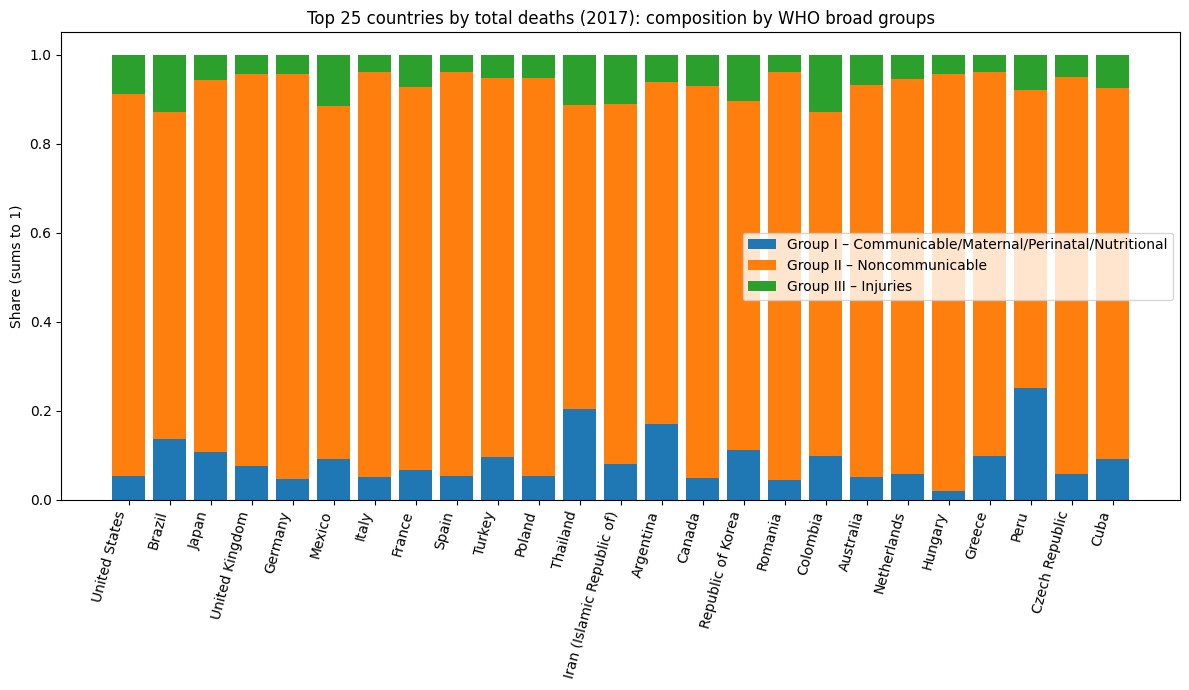

In [102]:
topN = 25
top = tab.sort_values("Total", ascending=False).head(topN)
top_props = top[GROUPS].div(top["Total"], axis=0)

plt.figure(figsize=(12, 7))
bottom = np.zeros(len(top_props))
xpos = np.arange(len(top_props))

for g in GROUPS:
    plt.bar(xpos, top_props[g].values, bottom=bottom, label=g)
    bottom += top_props[g].values

plt.xticks(xpos, top_props.index, rotation=75, ha="right")
plt.ylabel("Share (sums to 1)")
plt.title("Top 25 countries by total deaths (2017): composition by WHO broad groups")
plt.legend()
plt.tight_layout()
plt.show()


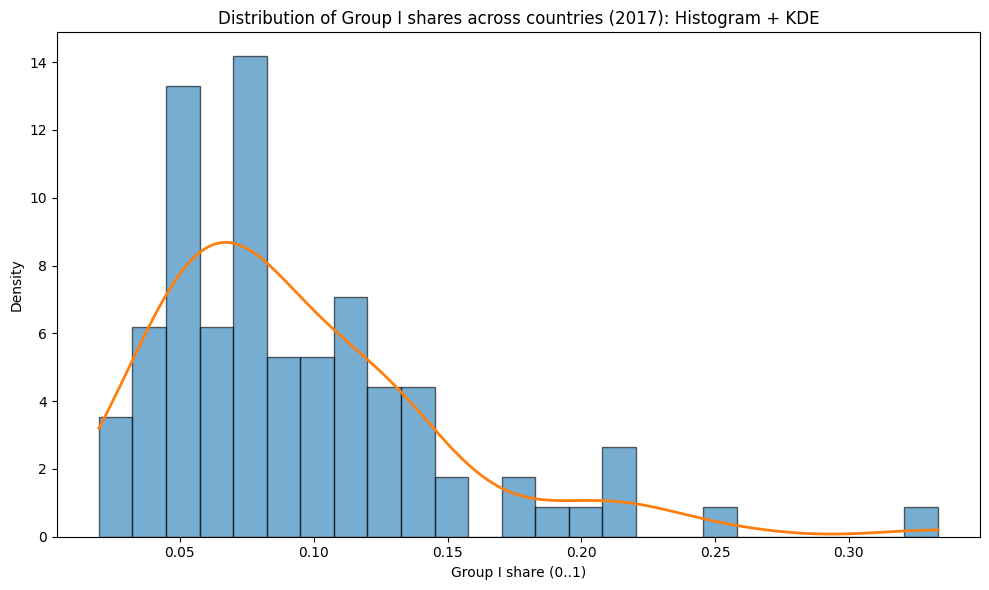

In [103]:
vals = props[GROUPS[0]].values  # Group I Anteil

plt.figure(figsize=(10, 6))
plt.hist(vals, bins=25, density=True, alpha=0.6, edgecolor="black")

kde = stats.gaussian_kde(vals)
xgrid = np.linspace(vals.min(), vals.max(), 400)
plt.plot(xgrid, kde(xgrid), linewidth=2)

plt.xlabel("Group I share (0..1)")
plt.ylabel("Density")
plt.title("Distribution of Group I shares across countries (2017): Histogram + KDE")
plt.tight_layout()
plt.show()


In [104]:
import scipy.stats as stats

GROUPS = [
    "Group I – Communicable/Maternal/Perinatal/Nutritional",
    "Group II – Noncommunicable",
    "Group III – Injuries",
]

FOCUS = ["Germany", "Peru"]

# Pivot: Deaths pro Gruppe
tab3 = (summary_all_countries
        .query("Country_clean in @FOCUS")
        .pivot(index="Country_clean", columns="GHE_group", values="Deaths1")
        .reindex(index=FOCUS, columns=GROUPS)
        .fillna(0))

tab3["Total"] = tab3.sum(axis=1)
props3 = tab3[GROUPS].div(tab3["Total"], axis=0)

tab3, props3


(GHE_group      Group I – Communicable/Maternal/Perinatal/Nutritional  \
 Country_clean                                                          
 Germany                                                        42824   
 Peru                                                           29014   
 
 GHE_group      Group II – Noncommunicable  Group III – Injuries   Total  
 Country_clean                                                            
 Germany                            820157                 39853  902834  
 Peru                                77113                  9042  115169  ,
 GHE_group      Group I – Communicable/Maternal/Perinatal/Nutritional  \
 Country_clean                                                          
 Germany                                                     0.047433   
 Peru                                                        0.251925   
 
 GHE_group      Group II – Noncommunicable  Group III – Injuries  
 Country_clean                              

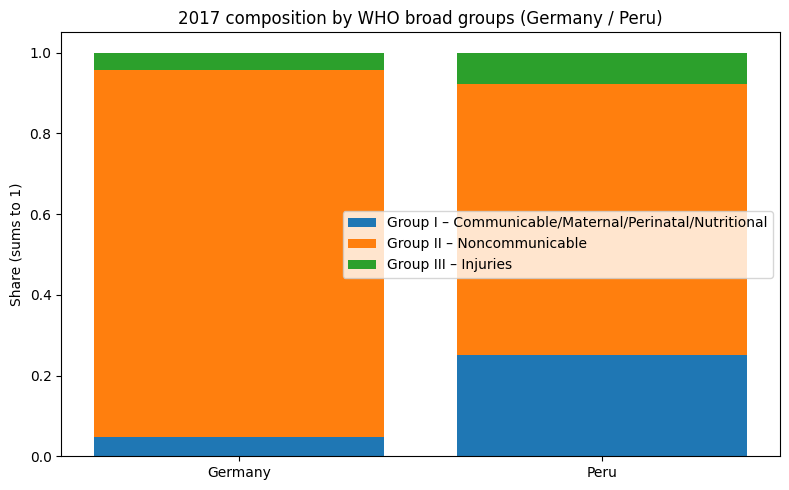

In [105]:
plt.figure(figsize=(8, 5))
bottom = np.zeros(len(FOCUS))
xpos = np.arange(len(FOCUS))

for g in GROUPS:
    plt.bar(xpos, props3[g].values, bottom=bottom, label=g)
    bottom += props3[g].values

plt.xticks(xpos, FOCUS)
plt.ylabel("Share (sums to 1)")
plt.title("2017 composition by WHO broad groups (Germany / Peru)")
plt.legend()
plt.tight_layout()
plt.show()


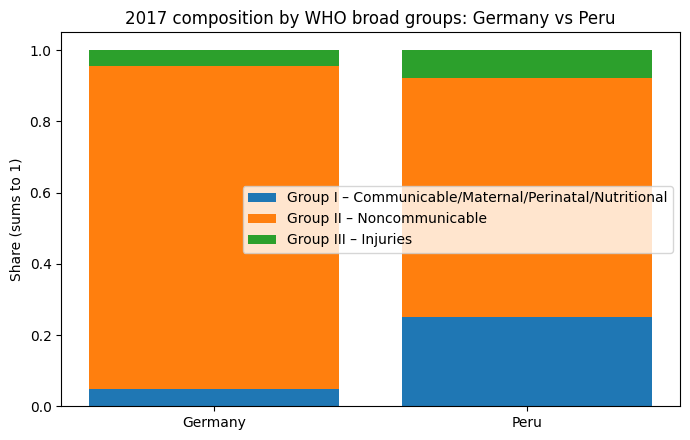

In [106]:
import numpy as np
import matplotlib.pyplot as plt

GROUPS = [
    "Group I – Communicable/Maternal/Perinatal/Nutritional",
    "Group II – Noncommunicable",
    "Group III – Injuries",
]
FOCUS = ["Germany", "Peru"]

tab2 = (summary_all_countries
        .query("Country_clean in @FOCUS")
        .pivot(index="Country_clean", columns="GHE_group", values="Deaths1")
        .reindex(index=FOCUS, columns=GROUPS)
        .fillna(0))

tab2["Total"] = tab2.sum(axis=1)
props2 = tab2[GROUPS].div(tab2["Total"], axis=0)

plt.figure(figsize=(7,4.5))
bottom = np.zeros(len(FOCUS))
x = np.arange(len(FOCUS))
for g in GROUPS:
    plt.bar(x, props2[g].values, bottom=bottom, label=g)
    bottom += props2[g].values
plt.xticks(x, FOCUS)
plt.ylabel("Share (sums to 1)")
plt.title("2017 composition by WHO broad groups: Germany vs Peru")
plt.legend()
plt.tight_layout()
plt.show()


In [90]:
import pandas as pd

# df_age_source muss die Alters-Spalten haben:
# Country_clean, Year, GHE_group, und die "Deaths at age ..." Spalten
df_age_source = df_clean  # nur korrekt, wenn df_clean die age cols wirklich enthält

age_cols = [c for c in df_age_source.columns if "Deaths at age" in c]
assert len(age_cols) > 0, "No age columns found. Use the raw WHO dataframe (with age columns)."

# numeric
df_age_source[age_cols] = df_age_source[age_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

FOCUS = ["Germany", "Peru"]

df_age = df_age_source[
    (df_age_source["Year"] == 2017) &
    (df_age_source["Country_clean"].isin(FOCUS)) &
    (df_age_source["GHE_group"].isin(GROUPS))
].copy()

by_age = df_age.groupby(["Country_clean", "GHE_group"], as_index=False)[age_cols].sum()

long_age = by_age.melt(
    id_vars=["Country_clean", "GHE_group"],
    value_vars=age_cols,
    var_name="AgeBand",
    value_name="Deaths"
)

totals = long_age.groupby(["Country_clean","AgeBand"])["Deaths"].transform("sum")
long_age["Share"] = np.where(totals > 0, long_age["Deaths"]/totals, 0.0)

age_order = age_cols  # keeps natural order

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for ax, country in zip(axes, FOCUS):
    sub = long_age[long_age["Country_clean"] == country]
    piv = (sub.pivot_table(index="AgeBand", columns="GHE_group", values="Share", aggfunc="sum")
             .reindex(index=age_order, fill_value=0)
             .reindex(columns=GROUPS, fill_value=0))

    bottom = np.zeros(len(piv))
    x = np.arange(len(piv))
    for g in GROUPS:
        ax.bar(x, piv[g].values, bottom=bottom, label=g)
        bottom += piv[g].values

    ax.set_title(country)
    ax.set_ylabel("Share")
    ax.set_ylim(0,1)

axes[-1].set_xticks(np.arange(len(age_order)))
axes[-1].set_xticklabels([a.replace("Deaths at age ","") for a in age_order],
                         rotation=75, ha="right")

axes[0].legend(loc="upper right")
fig.suptitle("2017 WHO broad-group composition by age band: Germany vs Peru", y=1.02)
plt.tight_layout()
plt.show()


AssertionError: No age columns found. Use the raw WHO dataframe (with age columns).